c:\Pyg\Assignment\MDER-MA\MDER-MA-Multimodal-Emotion-Recognition\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Device: cuda
  GPU: NVIDIA GeForce RTX 5060 Laptop GPU
  Memory: 8.5 GB
필터링: 성별 미표기 9개, chunk 파일 20개 제외
텍스트 파일: 1236
스펙트로그램 파일: 1276
매칭된 쌍: 1236


전처리 (화이트 이미지 필터링): 100%|██████████| 1236/1236 [00:07<00:00, 159.87it/s]



--- 전처리 결과 ---
제거: 화이트 이미지 0개, 빈 텍스트 0개, 성별 불명 0개
필터링 후 데이터: 1236개
label
Happy      312
Sad        341
Angry      271
Neutral    312
Name: count, dtype: int64

최종 데이터셋: 1236개

--- Class Distribution ---
label
Happy      312
Sad        341
Angry      271
Neutral    312
Name: count, dtype: int64

--- Gender Distribution ---
gender
male      659
female    577
Name: count, dtype: int64


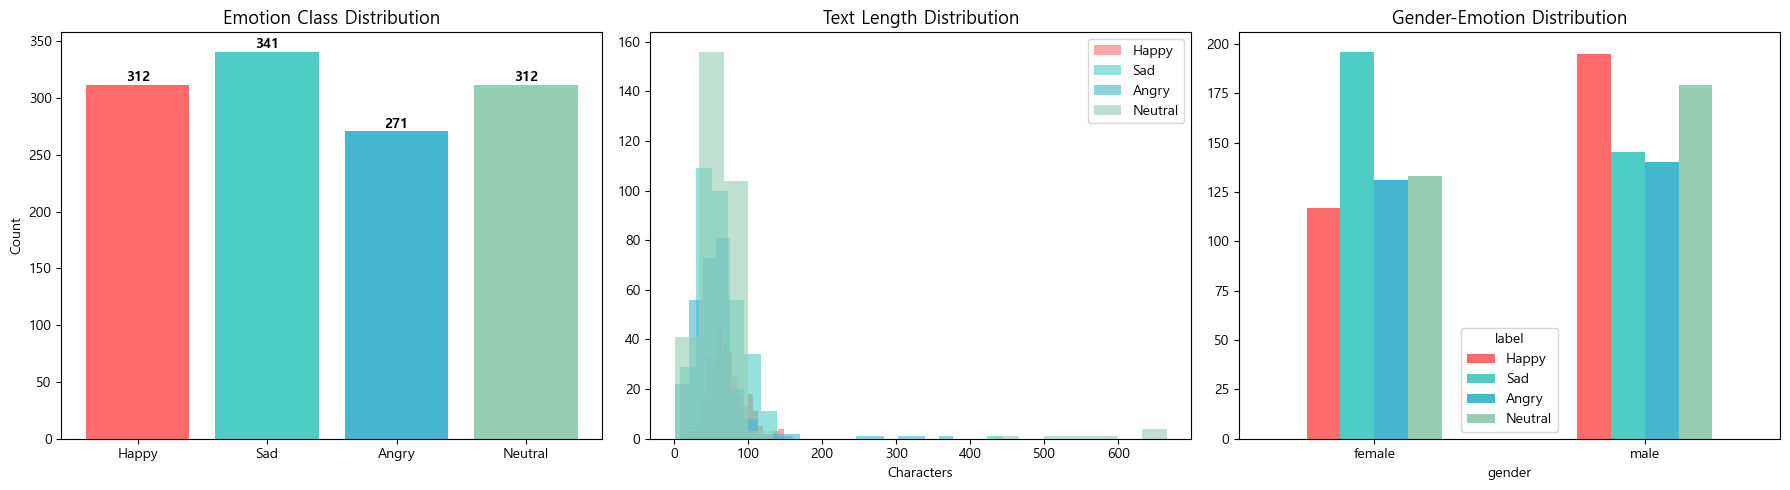

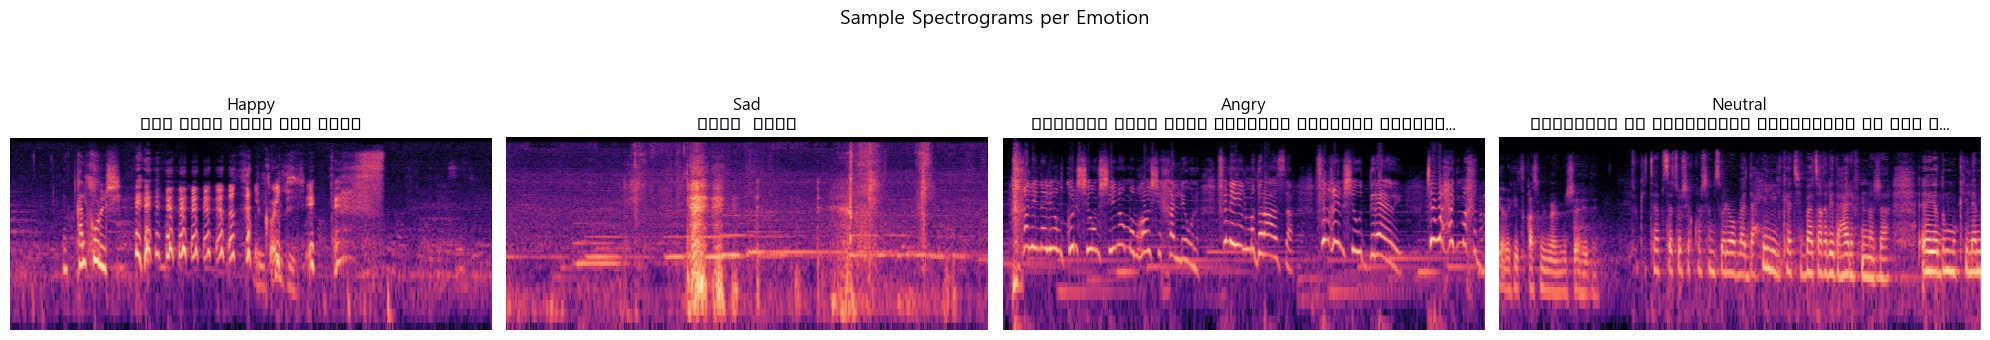

Split: train=865, val=185, test=186
Class weights: tensor([0.9853, 0.8988, 1.1306, 0.9853], device='cuda:0')


In [1]:
# ============================================================
# Model 4: XLM-RoBERTa + ViT-B/16 (Gated Fusion)
# ============================================================
# 텍스트: XLM-RoBERTa (mBERT보다 100개 언어 대규모 학습, 768-dim)
# 이미지: ViT-B/16 (Vision Transformer, 패치 기반 자기주의, 768-dim)
# Gated Fusion: sigmoid gate로 모달리티별 기여도 동적 조절
# ============================================================

from common import *

set_seed(42)
device = get_device()

# --- 데이터 설정 ---
DATA_CONFIG = DEFAULT_DATA_CONFIG.copy()
DATA_CONFIG['text_model_name'] = 'xlm-roberta-base'
DATA_CONFIG['image_model_name'] = 'vit_base_patch16_224'

df = load_data(DATA_CONFIG)
visualize_data(df)
train_ds, val_ds, test_ds, class_weights, tokenizer = prepare_datasets(df, DATA_CONFIG, device)

In [2]:
# ============================================================
# 모델 아키텍처
# ============================================================

class XLMRoBERTaViTGatedModel(nn.Module):
    def __init__(self, text_model_name, image_model_name,
                 text_hidden=768, image_hidden=768,
                 fusion_hidden=256, dropout=0.3, num_classes=4,
                 freeze_text=False, freeze_image=False):
        super().__init__()

        self.text_encoder = AutoModel.from_pretrained(text_model_name)
        self.image_encoder = timm.create_model(
            image_model_name, pretrained=True, num_classes=0)

        if freeze_text:
            for p in self.text_encoder.parameters():
                p.requires_grad = False
        if freeze_image:
            for p in self.image_encoder.parameters():
                p.requires_grad = False

        self.text_proj = nn.Sequential(
            nn.Linear(text_hidden, fusion_hidden),
            nn.ReLU(),
            nn.Dropout(dropout))

        self.image_proj = nn.Sequential(
            nn.Linear(image_hidden, fusion_hidden),
            nn.ReLU(),
            nn.Dropout(dropout))

        # Gating: [text, image] → sigmoid gate
        self.gate_network = nn.Sequential(
            nn.Linear(fusion_hidden * 2, fusion_hidden),
            nn.ReLU(),
            nn.Linear(fusion_hidden, fusion_hidden),
            nn.Sigmoid())

        self.classifier = nn.Sequential(
            nn.Linear(fusion_hidden, fusion_hidden),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(fusion_hidden, num_classes))

    def forward(self, input_ids, attention_mask, images):
        text_out = self.text_encoder(input_ids=input_ids, attention_mask=attention_mask)
        text_feat = self.text_proj(text_out.last_hidden_state[:, 0, :])  # [CLS]

        image_feat = self.image_proj(self.image_encoder(images))  # ViT class token

        combined = torch.cat([text_feat, image_feat], dim=1)
        gate = self.gate_network(combined)  # [B, D]

        # gate * text + (1-gate) * image
        fused = gate * text_feat + (1 - gate) * image_feat
        return self.classifier(fused)

In [3]:
# ============================================================
# 모델 & 학습 설정 (수정 가능)
# ============================================================

MODEL_CONFIG = {
    'text_model_name': DATA_CONFIG['text_model_name'],
    'image_model_name': DATA_CONFIG['image_model_name'],
    'text_hidden': 768,
    'image_hidden': 768,         # ViT-B/16 출력 768
    'fusion_hidden': 256,
    'dropout': 0.3,
    'num_classes': 4,
    'freeze_text': False,
    'freeze_image': False,
}

TRAIN_CONFIG = {
    'batch_size': 1,
    'encoder_lr': 2e-5,
    'classifier_lr': 1e-3,
    'weight_decay': 0.01,
    'num_epochs': 15,
    'patience': 5,
    'scheduler': 'cosine',
    'warmup_steps': 50,
    'max_grad_norm': 1.0,
}

In [ ]:
# ============================================================
# 학습 & 평가
# ============================================================

set_seed(DATA_CONFIG['random_seed'])

model = XLMRoBERTaViTGatedModel(**MODEL_CONFIG)

total_p = sum(p.numel() for p in model.parameters())
train_p = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Total params: {total_p:,}  Trainable: {train_p:,}')

result = train_and_evaluate(
    model, train_ds, val_ds, test_ds,
    TRAIN_CONFIG, class_weights, device)

del model
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 10519.59it/s]
XLMRobertaModel LOAD REPORT from: xlm-roberta-base
Key                       | Status     |  | 
--------------------------+------------+--+-
lm_head.dense.bias        | UNEXPECTED |  | 
lm_head.layer_norm.weight | UNEXPECTED |  | 
lm_head.layer_norm.bias   | UNEXPECTED |  | 
lm_head.dense.weight      | UNEXPECTED |  | 
lm_head.bias              | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Total params: 364,499,972  Trainable: 364,499,972


Epoch 1/15:  15%|█▍        | 128/865 [00:22<02:04,  5.91it/s, acc=0.1953, loss=1.0962]

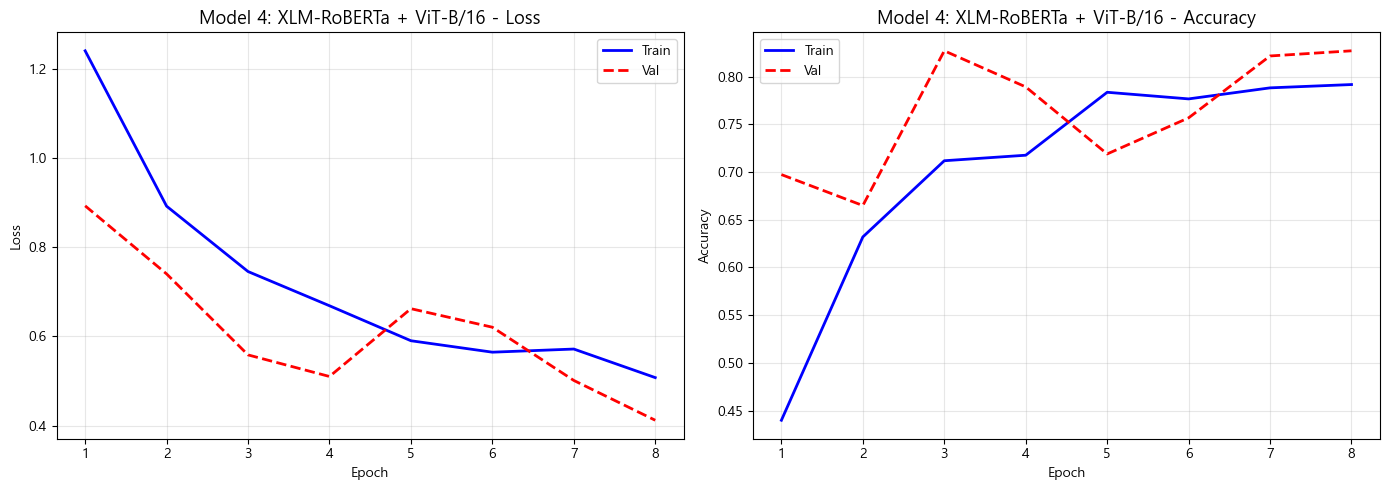

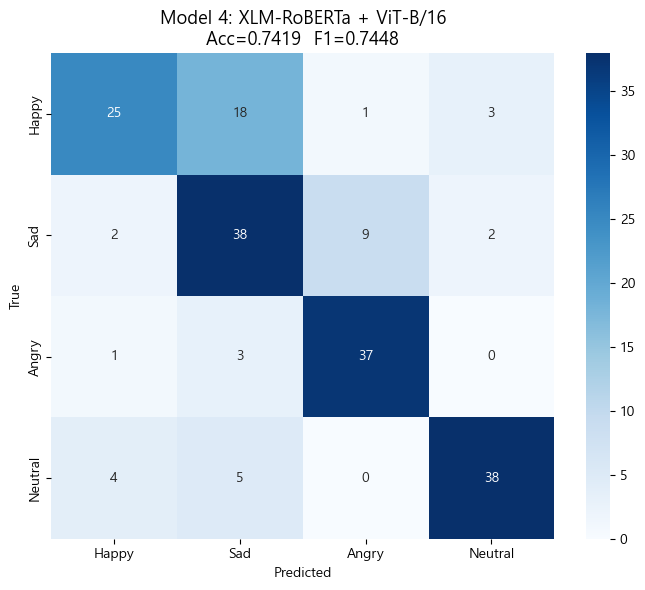


  Model 4: XLM-RoBERTa + ViT-B/16 - Classification Report
              precision    recall  f1-score   support

       Happy     0.7812    0.5319    0.6329        47
         Sad     0.5938    0.7451    0.6609        51
       Angry     0.7872    0.9024    0.8409        41
     Neutral     0.8837    0.8085    0.8444        47

    accuracy                         0.7419       186
   macro avg     0.7615    0.7470    0.7448       186
weighted avg     0.7571    0.7419    0.7399       186



In [ ]:
# ============================================================
# 결과 시각화
# ============================================================

plot_training_curves(result, 'Model 4: XLM-RoBERTa + ViT-B/16')
plot_confusion(result, 'Model 4: XLM-RoBERTa + ViT-B/16')
print_report(result, 'Model 4: XLM-RoBERTa + ViT-B/16')

```
Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Total params: 364,499,972  Trainable: 364,499,972
Epoch 1/15: 100%|██████████| 216/216 [01:05<00:00,  3.29it/s, acc=0.2870, loss=1.2699]
  => train_loss=1.4159 train_acc=0.2870 val_loss=1.2048 val_acc=0.4108
Epoch 2/15: 100%|██████████| 216/216 [02:56<00:00,  1.23it/s, acc=0.4583, loss=0.5538]
  => train_loss=1.1905 train_acc=0.4583 val_loss=0.9543 val_acc=0.6270
Epoch 3/15: 100%|██████████| 216/216 [01:23<00:00,  2.58it/s, acc=0.6852, loss=0.0164]
  => train_loss=0.8215 train_acc=0.6852 val_loss=0.6985 val_acc=0.8054
Epoch 4/15: 100%|██████████| 216/216 [03:53<00:00,  1.08s/it, acc=0.8461, loss=4.9486]
  => train_loss=0.7249 train_acc=0.8461 val_loss=0.6052 val_acc=0.8811
Epoch 5/15: 100%|██████████| 216/216 [02:26<00:00,  1.47it/s, acc=0.8935, loss=0.0004]
  => train_loss=0.5738 train_acc=0.8935 val_loss=0.8910 val_acc=0.9081
Epoch 6/15:  53%|█████▎    | 114/216 [01:56<01:43,  1.02s/it, acc=0.9123, loss=0.0003]
```

메모리 증가로 중간에 학습 중단 했지만, EfficientNet-B0보다 성능이 크게 향상된 것을 확인할 수 있습니다.
로컬로 돌리기엔 조금 무거워서 다른 모델을 먼저 실험중이다.